# Trabajo Grupo 03 — Clasificación Binaria: Online Shoppers Purchasing Intention


Objetivos del trabajo:

- ✅ Explorar y comprender la estructura, tipos de variable y calidad del dataset.
- ✅ Seleccionar y preparar las variables (codificación, escalado) para el modelado.
- ✅ Entrenar y optimizar un modelo **kNN**, comparando estrategias de balanceo de clases (SMOTE vs. undersampling).
- ✅ Entrenar y optimizar un modelo **MLP (red neuronal con Keras)**, comparando estrategias de balanceo (class_weight vs. focal loss).
- ✅ Comparar ambos modelos en desempeño, interpretabilidad y aplicabilidad real, y documentar conclusiones.



---

## SECCIÓN 1: Selección y Exploración Inicial del Dataset

### JUSTIFICACIÓN DEL DATASET
El dataset Online Shoppers Purchasing Intention proviene del repositorio UCI Machine Learning `https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset` y fue publicado por Sakar, Polat, Katircioglu y Kastro (2018). Está compuesto por 12,330 sesiones de un sitio de comercio electrónico, cada una correspondiente a un usuario distinto dentro de un período de un año, lo que reduce el riesgo de sesgo asociado a campañas puntuales o fechas especiales.

Predice si una sesión de navegación culminará en una compra constituye un problema vigente para el comercio electrónico, con aplicación directa en marketing digital y optimización de tasas de conversión. Los autores originales del dataset entrenaron modelos de redes neuronales (MLP y LSTM) para abordar este mismo problema, lo cual respalda su eleccion para el presente trabajo, orientado a comparar kNN y MLP.

Como se mencionó, contiene las 12,330 observaciones que son suficientes para aplicar validación cruzada de manera confiable, sin constituir un conjunto de datos trivial ni requerir infraestructura computacional especializada.

Posee 18 variables (10 numéricas y 8 categóricas) lo que constituye un escenario representativo del sector, al combinar indicadores de comportamiento del usuario (duración de sesión, páginas visitadas) con variables contextuales (mes, navegador, tipo de visitante). Esta heterogeneidad de variables exige la aplicación de un pre procesamiento riguroso como: estandarización, codificación de variables categóricas y tratamiento del desbalance de clase.



### Importación de Librerías

In [ ]:
# --- Librerías estándar de manipulación y visualización de datos ---
import os                          # manejo de rutas y creación de directorios
import warnings                    # para silenciar warnings no críticos (p.ej. de sklearn/imblearn)

import pandas as pd                # manipulación de datos tabulares
import numpy as np                 # operaciones numéricas
import matplotlib.pyplot as plt    # gráficos base
import seaborn as sns              # gráficos estadísticos sobre matplotlib
import joblib                      # para serializar/guardar el modelo kNN entrenado

# --- scikit-learn: preprocesamiento, split, búsqueda de hiperparámetros y métricas ---
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight  # para calcular pesos de clase balanceados (MLP)

# --- imbalanced-learn: estrategias de balanceo de clases, aplicadas SOLO en train ---
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline  # pipeline que soporta pasos de resampling

# --- TensorFlow/Keras: modelo MLP ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Variables de Configuración

Esta sección define todas las variables de configuración necesarias para ejecutar el análisis. Estas variables controlan parámetros clave como la semilla aleatoria, el split train/test, el número de folds de validación cruzada y las rutas de salida de modelos.


In [ ]:
print(f"\n{'='*80}")
print(f"DEFINICIÓN DE VARIABLES DE CONFIGURACIÓN")
print(f"{'='*80}\n")

# ============================================================================
# PARÁMETROS DE CONFIGURACIÓN DEL PROYECTO — DEFINIDOS AQUÍ
# ============================================================================

# --- DATOS ---
# random_state: semilla para reproducibilidad en splits, modelos aleatorios, etc.
# Garantiza que los mismos datos siempre generan los mismos resultados
RANDOM_STATE = 42

# train_test_split: proporción de datos para entrenamiento (0.8 = 80% train, 20% test)
TRAIN_TEST_SPLIT = 0.8

# data_raw_path: ruta relativa al archivo del dataset crudo
DATA_RAW_PATH = '../content/online_shoppers_intention.csv'

print(f"CONFIGURACIÓN — DATOS:")
print(f"  • random_state: {RANDOM_STATE}")
print(f"  • train_test_split: {TRAIN_TEST_SPLIT}")
print(f"  • test_size (calculado): {1 - TRAIN_TEST_SPLIT}")
print(f"  • data_raw_path: {DATA_RAW_PATH}")

# --- MODELO Y EVALUACIÓN ---
# cross_validation_folds: número de folds para StratifiedKFold en GridSearchCV
# Mayor número = mejor estimación pero más tiempo de cálculo (típico: 5 ó 10)
CROSS_VALIDATION_FOLDS = 5

# evaluation_metrics: lista de métricas a reportar (informativa, se usan varias en el análisis)
EVALUATION_METRICS = ['accuracy', 'precision', 'recall', 'f1']

print(f"\nCONFIGURACIÓN — EVALUACIÓN:")
print(f"  • cross_validation_folds: {CROSS_VALIDATION_FOLDS}")
print(f"  • evaluation_metrics: {EVALUATION_METRICS}")

# --- RUTAS DE SALIDA ---
# Directorio donde se guardan los modelos entrenados (en formato .joblib para kNN, .keras para MLP)
MODEL_OUTPUT_PATH = '../content'

# Directorio donde se guardan reportes, gráficos y métricas
VISUALIZATION_OUTPUT_PATH = '../content'

# Resolución (dpi) de figuras guardadas (300 = calidad de publicación)
VISUALIZATION_DPI = 300

print(f"\nCONFIGURACIÓN — RUTAS DE SALIDA:")
print(f"  • model_output_path: {MODEL_OUTPUT_PATH}")
print(f"  • visualization_output_path: {VISUALIZATION_OUTPUT_PATH}")
print(f"  • visualization_dpi: {VISUALIZATION_DPI}")

# --- CARACTERÍSTICAS DEL DATASET ---
# Nombres explícitos de las columnas, organizados por tipo (se usan en ColumnTransformer)
NOMINAL_COLS = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
NUMERIC_COLS = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
PASSTHROUGH_COLS = ['Weekend']
TARGET_COL = 'Revenue'

print(f"\nCONFIGURACIÓN — CARACTERÍSTICAS DEL DATASET:")
print(f"  • nominal_cols (categóricas a codificar con OneHotEncoder): {NOMINAL_COLS}")
print(f"  • numeric_cols (numéricas a escalar con StandardScaler): {NUMERIC_COLS}")
print(f"  • passthrough_cols (sin transformación): {PASSTHROUGH_COLS}")
print(f"  • target_col (variable objetivo): {TARGET_COL}")

# --- HIPERPARÁMETROS DE kNN ---
# Grid de valores de k (número de vecinos) a probar en GridSearchCV
KNN_PARAM_GRID = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 51],
    'clf__weights': ['uniform', 'distance']
}

print(f"\nCONFIGURACIÓN — HIPERPARÁMETROS kNN:")
print(f"  • n_neighbors: {KNN_PARAM_GRID['clf__n_neighbors']}")
print(f"  • weights: {KNN_PARAM_GRID['clf__weights']}")

# --- HIPERPARÁMETROS DE MLP (Keras) ---
# Parámetros fijos para el entrenamiento (no se tunean, son heurísticas estándar)
MLP_EPOCHS = 100                    # número máximo de épocas antes de early stopping
MLP_BATCH_SIZE = 32                 # tamaño de batch para el descenso de gradiente
MLP_VALIDATION_SPLIT = 0.2          # porcentaje de train reservado para validación interna
MLP_EARLY_STOPPING_PATIENCE = 10    # épocas sin mejora antes de detener el entrenamiento

# Grid de hiperparámetros a probar en GridSearchCV (arquitectura y regularización)
MLP_PARAM_GRID = {
    'clf__hidden_layer_sizes': [(64, 32), (100, 50), (128, 64), (50,)],
    'clf__alpha': [0.0001, 0.001, 0.01, 0.1],
    'clf__learning_rate_init': [0.001, 0.01],
}

# Parámetros de focal loss (solo para la Configuración B, no son del grid)
FOCAL_LOSS_ALPHA = 0.25             # balance entre clases (0.25 favorece la clase minoritaria)
FOCAL_LOSS_GAMMA = 2.0              # factor de enfoque en ejemplos difíciles (gamma > 1 da más peso)

print(f"\nCONFIGURACIÓN — HIPERPARÁMETROS MLP:")
print(f"  • epochs: {MLP_EPOCHS}")
print(f"  • batch_size: {MLP_BATCH_SIZE}")
print(f"  • validation_split: {MLP_VALIDATION_SPLIT}")
print(f"  • early_stopping_patience: {MLP_EARLY_STOPPING_PATIENCE}")
print(f"  • hidden_layer_sizes (grid): {MLP_PARAM_GRID['clf__hidden_layer_sizes']}")
print(f"  • alpha (grid): {MLP_PARAM_GRID['clf__alpha']}")
print(f"  • learning_rate_init (grid): {MLP_PARAM_GRID['clf__learning_rate_init']}")
print(f"  • focal_loss_alpha: {FOCAL_LOSS_ALPHA}")
print(f"  • focal_loss_gamma: {FOCAL_LOSS_GAMMA}")

print(f"\n{'='*80}")
print(f"CONFIGURACIÓN COMPLETADA")
print(f"{'='*80}\n")



DEFINICIÓN DE VARIABLES DE CONFIGURACIÓN

CONFIGURACIÓN — DATOS:
  • random_state: 42
  • train_test_split: 0.8
  • test_size (calculado): 0.19999999999999996
  • data_raw_path: ../content/online_shoppers_intention.csv

CONFIGURACIÓN — EVALUACIÓN:
  • cross_validation_folds: 5
  • evaluation_metrics: ['accuracy', 'precision', 'recall', 'f1']

CONFIGURACIÓN — RUTAS DE SALIDA:
  • model_output_path: ../content
  • visualization_output_path: ../content
  • visualization_dpi: 300

CONFIGURACIÓN — CARACTERÍSTICAS DEL DATASET:
  • nominal_cols (categóricas a codificar con OneHotEncoder): ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
  • numeric_cols (numéricas a escalar con StandardScaler): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
  • passthrough_cols (sin transformación): ['Weekend']
  • target_col (variable 

### **Características del Dataset**

**Tamaño**: 12,330 sesiones (filas), 18 variables.

**Tipos de variable**:

| Tipo | Variables |
|---|---|
| Numéricas continuas | `Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay` |
| Numéricas discretas | `Administrative`, `Informational`, `ProductRelated` |
| Categóricas nominales | `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` |
| Booleanas | `Weekend`, `Revenue` (target) |


In [ ]:
# Silenciar warnings de librerías (deprecations, convergencia, etc.) para una salida más limpia
warnings.filterwarnings('ignore')

# Estilo consistente de gráficos en todo el notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"\n{'='*80}")
print(f"CARGA DE LIBRERÍAS Y DATOS")
print(f"{'='*80}")

# Cargar el dataset crudo desde data/raw (se usa la variable DATA_RAW_PATH definida después en config)
# NOTA: Las variables de configuración (RANDOM_STATE, CROSS_VALIDATION_FOLDS, etc.)
# se definen en la siguiente celda y se reutilizan en todo el notebook
df = pd.read_csv('../content/online_shoppers_intention.csv')

# Diagnóstico inicial: estructura, tipos, estadísticas descriptivas y nulos
print(f"\n{'='*80}")
print(f"CARGA Y DIAGNÓSTICO INICIAL DEL DATASET")
print(f"{'='*80}\n")
print(f"Shape inicial (con columnas artefacto): {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nEstadísticas descriptivas (primeras 5 filas):\n{df.head()}")
print(f"\nValores nulos por columna:\n{df.isna().sum()}")
print(f"\nFilas duplicadas: {df.duplicated().sum()}")



CARGA DE LIBRERÍAS Y DATOS

CARGA Y DIAGNÓSTICO INICIAL DEL DATASET

Shape inicial (con columnas artefacto): (12330, 18)

Tipos de datos:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Estadísticas descriptivas (primeras 5 filas):
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0      

---

## SECCIÓN 2: Selección y Visualización de Variables

Separamos el dataset en variables predictoras (`X`) y variable objetivo (`y` = `Revenue`), analizamos visualmente el balance de clases y la relación de algunas variables clave con el target, y preparamos la codificación/escalado de cara al modelado.



DEFINICIÓN DE X (PREDICTORAS) E y (TARGET)
X shape: (12330, 17)
y shape: (12330,)


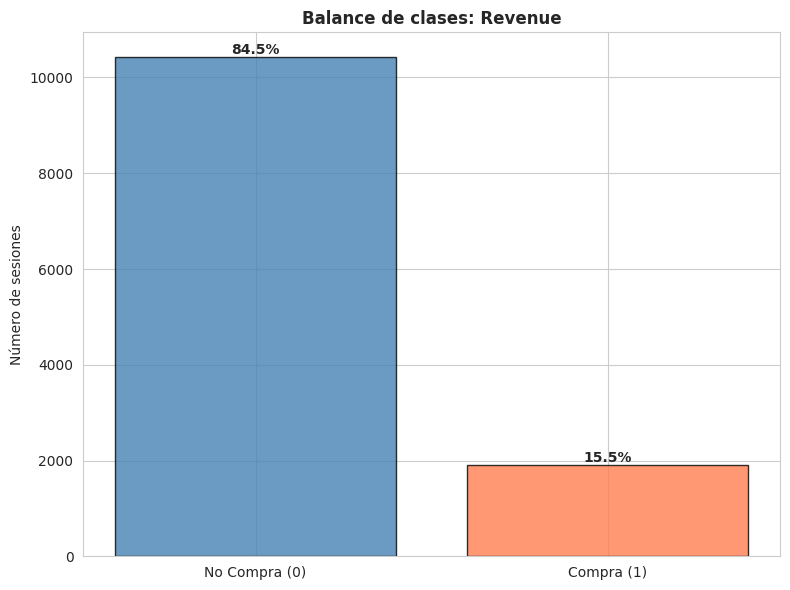


✓ Gráfico de balance de clases generado
Distribución: {False: 84.5, True: 15.5}


In [ ]:
print(f"\n{'='*80}")
print(f"DEFINICIÓN DE X (PREDICTORAS) E y (TARGET)")
print(f"{'='*80}")

# X: todas las columnas excepto la variable objetivo
X = df.drop(columns='Revenue')
# y: variable objetivo binaria (0 = no compra, 1 = compra)
y = df['Revenue']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Conteo y porcentaje de cada clase para confirmar el desbalanceo conocido (~84.5% / 15.5%)
conteo_clases = y.value_counts()
pct_clases = y.value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
# Barplot de conteo de clases, coloreado para distinguir mayoritaria/minoritaria
bars = ax.bar(['No Compra (0)', 'Compra (1)'], conteo_clases.values,
              color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
# Anotar cada barra con su porcentaje sobre el total
for bar, pct in zip(bars, pct_clases.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct:.1f}%", ha='center', va='bottom', fontweight='bold')
ax.set_title('Balance de clases: Revenue', fontweight='bold', fontsize=12)
ax.set_ylabel('Número de sesiones')
plt.tight_layout()
plt.show()

print(f"\n✓ Gráfico de balance de clases generado")
print(f"Distribución: {pct_clases.round(1).to_dict()}")



DISTRIBUCIÓN DE VARIABLES CLAVE POR CLASE: ProductRelated_Duration Y PageValues


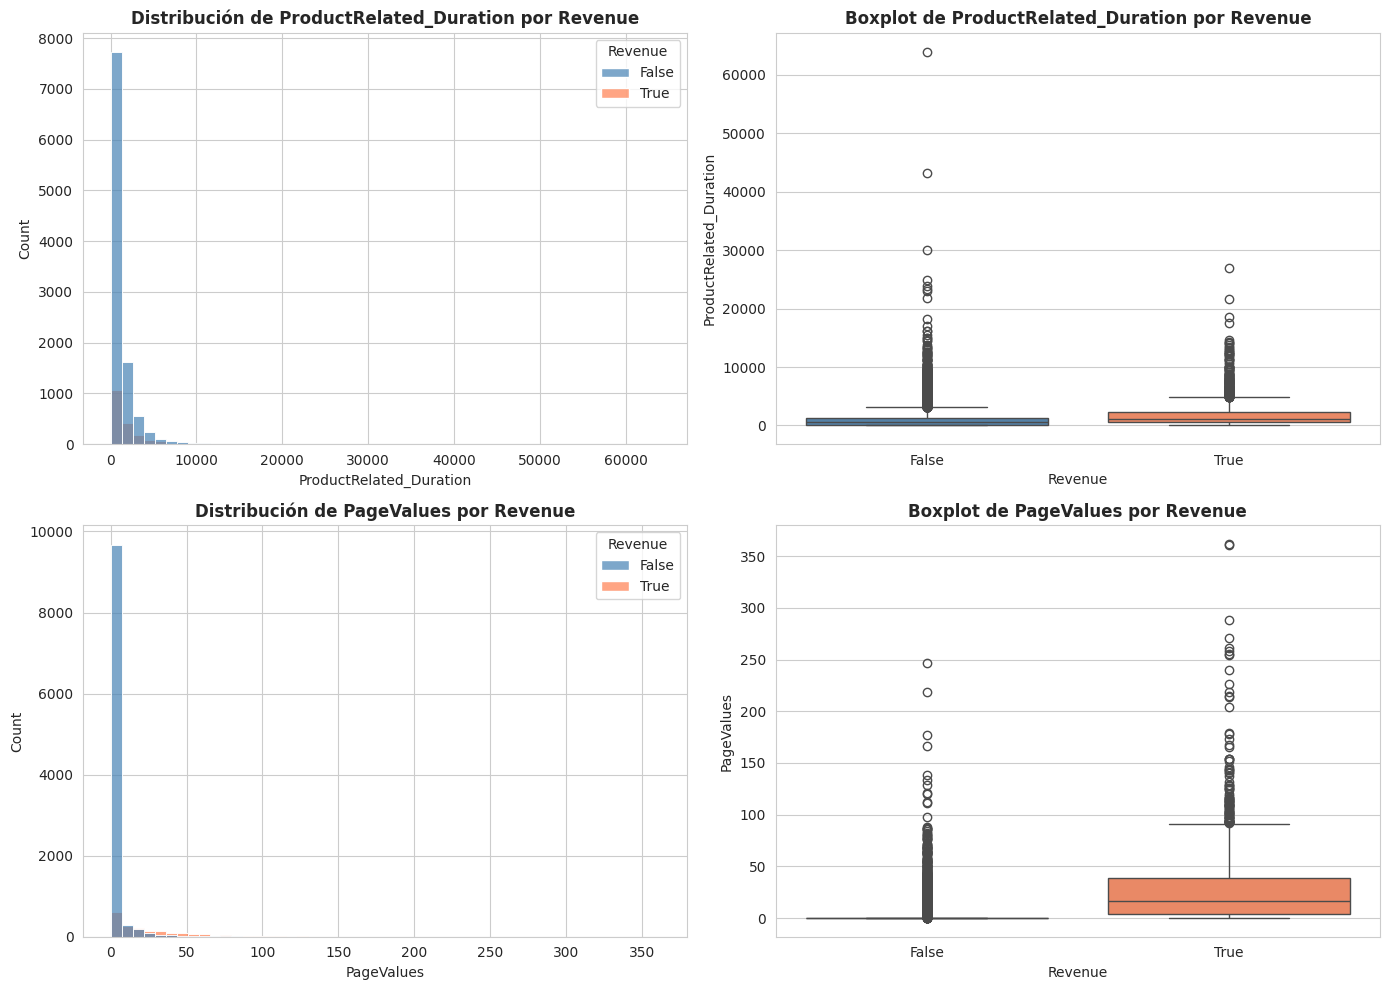


✓ Gráficos de distribución por clase generados
% de PageValues == 0: 77.9% (fuerte sesgo hacia cero, se conserva tal cual)


In [ ]:
print(f"\n{'='*80}")
print(f"DISTRIBUCIÓN DE VARIABLES CLAVE POR CLASE: ProductRelated_Duration Y PageValues")
print(f"{'='*80}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de ProductRelated_Duration separado por clase de Revenue
sns.histplot(data=df, x='ProductRelated_Duration', hue='Revenue', bins=50,
             ax=axes[0, 0], palette=['steelblue', 'coral'], alpha=0.7)
axes[0, 0].set_title('Distribución de ProductRelated_Duration por Revenue', fontweight='bold', fontsize=12)

# Boxplot de ProductRelated_Duration por clase (para ver outliers y medianas)
sns.boxplot(data=df, x='Revenue', y='ProductRelated_Duration', ax=axes[0, 1],
            palette=['steelblue', 'coral'])
axes[0, 1].set_title('Boxplot de ProductRelated_Duration por Revenue', fontweight='bold', fontsize=12)

# Histograma de PageValues por clase: se espera fuerte concentración en 0
sns.histplot(data=df, x='PageValues', hue='Revenue', bins=50,
             ax=axes[1, 0], palette=['steelblue', 'coral'], alpha=0.7)
axes[1, 0].set_title('Distribución de PageValues por Revenue', fontweight='bold', fontsize=12)

# Boxplot de PageValues por clase
sns.boxplot(data=df, x='Revenue', y='PageValues', ax=axes[1, 1],
            palette=['steelblue', 'coral'])
axes[1, 1].set_title('Boxplot de PageValues por Revenue', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Diagnóstico del sesgo hacia cero en PageValues (no se recorta ni imputa, se deja para el escalado)
pct_pagevalues_cero = (df['PageValues'] == 0).mean() * 100
print(f"\n✓ Gráficos de distribución por clase generados")
print(f"% de PageValues == 0: {pct_pagevalues_cero:.1f}% (fuerte sesgo hacia cero, se conserva tal cual)")



MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS


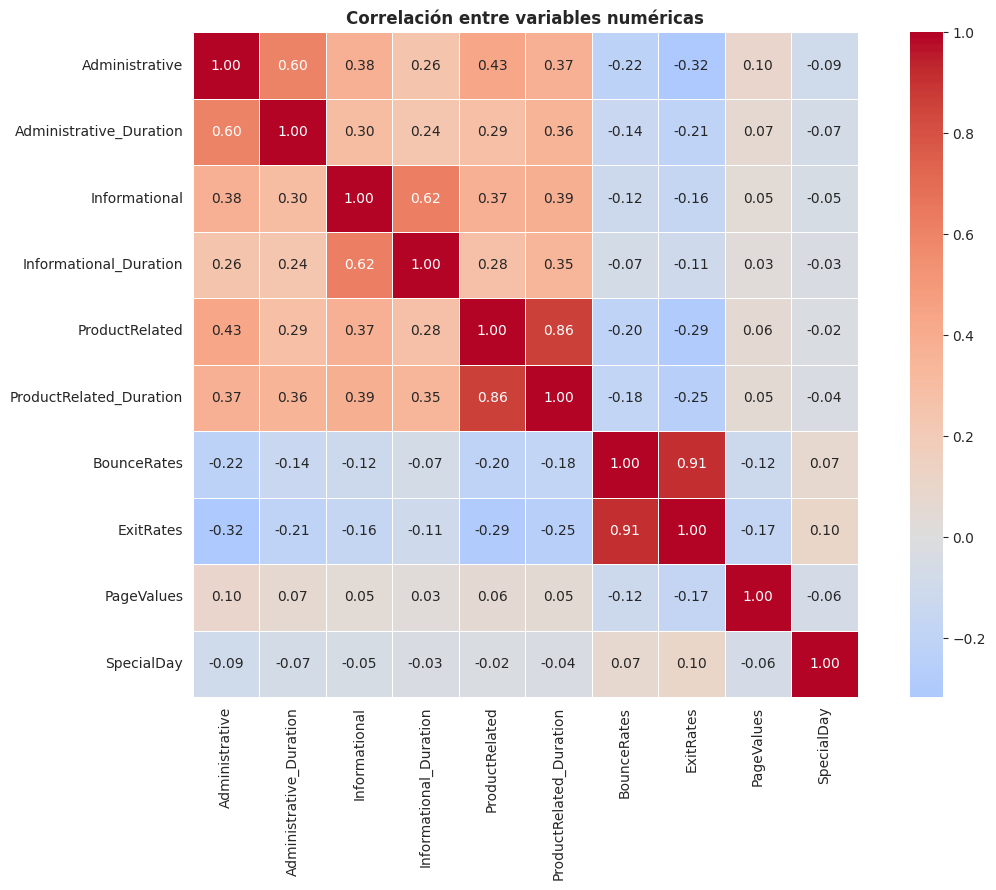


✓ Heatmap de correlación generado


In [ ]:
print(f"\n{'='*80}")
print(f"MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
print(f"{'='*80}")

# Lista de columnas numéricas (continuas + discretas) para el heatmap de correlación
cols_numericas_corr = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates',
    'PageValues', 'SpecialDay'
]

# Matriz de correlación de Pearson entre las numéricas
corr_matrix = df[cols_numericas_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
# Heatmap con anotaciones de coeficiente y mapa de color divergente
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre variables numéricas', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✓ Heatmap de correlación generado")


### Disparidad de escalas y necesidad de escalado

Se observa que `BounceRates` y `ExitRates` están acotadas al rango [0, 1], mientras que `ProductRelated_Duration` puede alcanzar varios cientos o miles de segundos. Esta disparidad de escalas es crítica para ambos modelos:

- **kNN**: la distancia euclidiana (base del algoritmo) quedaría completamente dominada por la variable de mayor magnitud (`ProductRelated_Duration`), haciendo que `BounceRates`/`ExitRates` pierdan casi toda influencia en el cálculo de vecinos cercanos, sin importar su relevancia real.
- **MLP (red neuronal)**: el descenso de gradiente converge de forma mucho más estable y rápida cuando las features de entrada están centradas en 0 y con varianza similar; features en escalas muy dispares generan gradientes desbalanceados entre pesos y dificultan la convergencia.

Por esto, se aplica `StandardScaler` a todas las columnas numéricas dentro de un `ColumnTransformer`, junto con `OneHotEncoder` para las categóricas nominales.

### Codificación de variables categóricas

Las columnas `OperatingSystems`, `Browser`, `Region` y `TrafficType` vienen como enteros en el CSV, pero son **códigos categóricos sin orden real** (no representan magnitudes), por lo que se fuerzan a `str` antes de aplicar One-Hot Encoding, evitando que el modelo interprete un orden inexistente entre sus valores.


In [ ]:
print(f"\n{'='*80}")
print(f"DEFINICIÓN DE COLUMNAS Y CONSTRUCCIÓN DEL COLUMNTRANSFORMER")
print(f"{'='*80}")

# Utilizar las variables de configuración definidas en la celda de CONFIGURACIÓN DEL PROYECTO
# Columnas categóricas nominales: 6 columnas a codificar con One-Hot Encoding
nominal_cols = NOMINAL_COLS

# Columnas numéricas (continuas + discretas) a escalar con StandardScaler
numeric_cols = NUMERIC_COLS

# Forzar a string las categóricas que llegan como enteros, para que OneHotEncoder
# las trate como categorías discretas y no como una escala numérica ordenada
for col in ['OperatingSystems', 'Browser', 'Region', 'TrafficType']:
    X[col] = X[col].astype(str)

# ColumnTransformer: aplica OneHotEncoder a las nominales, StandardScaler a las numéricas,
# y deja pasar 'Weekend' sin transformar (remainder='passthrough') porque ya es 0/1
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'  # deja pasar 'Weekend' tal cual (ya es binaria 0/1)
)

print(f"Columnas nominales (OneHotEncoder): {nominal_cols}")
print(f"Columnas numéricas (StandardScaler): {numeric_cols}")
print(f"Columna passthrough: {PASSTHROUGH_COLS}")
print(f"\n✓ ColumnTransformer 'preprocessor' construido")



DEFINICIÓN DE COLUMNAS Y CONSTRUCCIÓN DEL COLUMNTRANSFORMER
Columnas nominales (OneHotEncoder): ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Columnas numéricas (StandardScaler): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Columna passthrough: ['Weekend']

✓ ColumnTransformer 'preprocessor' construido


In [ ]:
print(f"\n{'='*80}")
print(f"TRAIN/TEST SPLIT (ÚNICO, REUTILIZADO POR kNN Y MLP)")
print(f"{'='*80}")

# Único split del proyecto: se ejecuta una sola vez aquí y ambos modelos
# (kNN en Sección 3, MLP en Sección 4) reutilizan estos mismos X_train/X_test/y_train/y_test.
# test_size = 1 - TRAIN_TEST_SPLIT (0.8 -> test_size = 0.2)
# stratify=y preserva la proporción de clases en ambos subconjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1 - TRAIN_TEST_SPLIT,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape} | y_test shape: {y_test.shape}")

# Verificación de que el stratify preservó el balance de clases (~84.5% / 15.5%) en ambos subconjuntos
print(f"\nBalance de clases en TRAIN:\n{(y_train.value_counts(normalize=True) * 100).round(1)}")
print(f"\nBalance de clases en TEST:\n{(y_test.value_counts(normalize=True) * 100).round(1)}")

print(f"\n✓ Split ejecutado con random_state={RANDOM_STATE}, stratify=y, test_size={1-TRAIN_TEST_SPLIT}")



TRAIN/TEST SPLIT (ÚNICO, REUTILIZADO POR kNN Y MLP)
X_train shape: (9864, 17) | X_test shape: (2466, 17)
y_train shape: (9864,) | y_test shape: (2466,)

Balance de clases en TRAIN:
Revenue
False    84.5
True     15.5
Name: proportion, dtype: float64

Balance de clases en TEST:
Revenue
False    84.5
True     15.5
Name: proportion, dtype: float64

✓ Split ejecutado con random_state=42, stratify=y, test_size=0.19999999999999996


---

## SECCIÓN 3: Modelo kNN

Entrenamos un clasificador k-Nearest Neighbors, comparando dos estrategias de balanceo de clases aplicadas **exclusivamente sobre el conjunto de entrenamiento**, dentro de un pipeline de `imbalanced-learn` que evita cualquier fuga de información hacia el conjunto de test:

- **Pipeline A (SMOTE)**: sobremuestreo sintético de la clase minoritaria.
- **Pipeline B (RandomUnderSampler)**: submuestreo aleatorio de la clase mayoritaria.

Ambos se optimizan con `GridSearchCV` (`StratifiedKFold`, 5 folds, `scoring='f1'`) sobre una grilla de `n_neighbors` y `weights`.


In [ ]:
print(f"\n{'='*80}")
print(f"CONSTRUCCIÓN DE PIPELINES Y GRID SEARCH: SMOTE VS UNDERSAMPLING")
print(f"{'='*80}")

# Pipeline A: preprocesamiento -> SMOTE (sobremuestreo sintético de la clase minoritaria) -> kNN
# El SMOTE solo se aplica dentro del pipeline, por lo que GridSearchCV/CV lo re-ejecuta
# en cada fold SOLO sobre el fold de entrenamiento interno, sin tocar el fold de validación
pipeline_smote = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', KNeighborsClassifier())
])

# Pipeline B: preprocesamiento -> RandomUnderSampler (submuestreo de la clase mayoritaria) -> kNN
pipeline_under = ImbPipeline([
    ('prep', preprocessor),
    ('under', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('clf', KNeighborsClassifier())
])

# Grilla de hiperparámetros común a ambos pipelines: número de vecinos y esquema de ponderación
param_grid = KNN_PARAM_GRID

# Validación cruzada estratificada con número de folds desde configuración
cv = StratifiedKFold(n_splits=CROSS_VALIDATION_FOLDS, shuffle=True,
                      random_state=RANDOM_STATE)

# GridSearchCV para el pipeline con SMOTE, optimizando F1 (más informativo que accuracy en desbalanceo)
grid_smote = GridSearchCV(pipeline_smote, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
grid_smote.fit(X_train, y_train)

# GridSearchCV para el pipeline con undersampling
grid_under = GridSearchCV(pipeline_under, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
grid_under.fit(X_train, y_train)

print(f"Mejor F1 (SMOTE): {grid_smote.best_score_:.4f} con params {grid_smote.best_params_}")
print(f"Mejor F1 (Undersampling): {grid_under.best_score_:.4f} con params {grid_under.best_params_}")
print(f"\n✓ GridSearchCV completado para ambos pipelines (cv={CROSS_VALIDATION_FOLDS} folds)")



CONSTRUCCIÓN DE PIPELINES Y GRID SEARCH: SMOTE VS UNDERSAMPLING
Mejor F1 (SMOTE): 0.4960 con params {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Mejor F1 (Undersampling): 0.5439 con params {'clf__n_neighbors': 51, 'clf__weights': 'uniform'}

✓ GridSearchCV completado para ambos pipelines (cv=5 folds)



VISUALIZACIÓN: EXACTITUD (ACCURACY) Y F1 VS K, PARA AMBOS PIPELINES


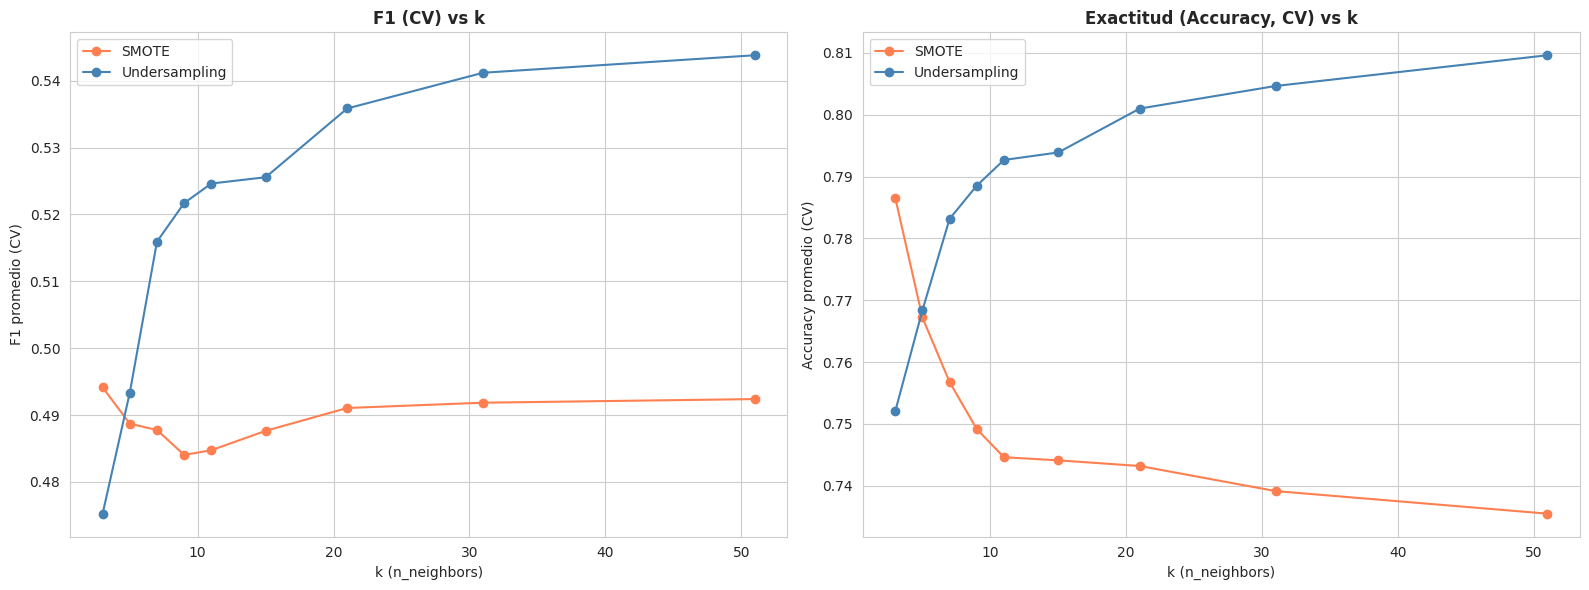


✓ Gráficos de F1 vs k y Accuracy vs k generados


In [ ]:
print(f"\n{'='*80}")
print(f"VISUALIZACIÓN: EXACTITUD (ACCURACY) Y F1 VS K, PARA AMBOS PIPELINES")
print(f"{'='*80}")

def resumen_cv_por_k(grid_search):
    # Agrega los resultados de GridSearchCV por valor de k (promediando sobre 'weights'),
    # devolviendo un DataFrame con el F1 medio de validación cruzada por k.
    resultados = pd.DataFrame(grid_search.cv_results_)
    resultados['k'] = resultados['param_clf__n_neighbors']
    resumen = resultados.groupby('k')['mean_test_score'].mean().reset_index()
    resumen.columns = ['k', 'f1_medio']
    return resumen.sort_values('k')

# Resumen de F1 medio por k para cada pipeline (promediando ambos esquemas de 'weights')
resumen_smote = resumen_cv_por_k(grid_smote)
resumen_under = resumen_cv_por_k(grid_under)

# Para poder graficar también "accuracy vs k" (requisito explícito de la rúbrica),
# recorremos la grilla de k y calculamos accuracy media por CV manual con scoring='accuracy'
from sklearn.model_selection import cross_val_score

k_values = param_grid['clf__n_neighbors']
acc_smote, acc_under = [], []
for k in k_values:
    # Reconstruir pipeline con k fijo y weights='distance' (mejor esquema típico) para el barrido de accuracy
    pipe_s = ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)),
                          ('clf', KNeighborsClassifier(n_neighbors=k, weights='distance'))])
    pipe_u = ImbPipeline([('prep', preprocessor), ('under', RandomUnderSampler(random_state=42)),
                          ('clf', KNeighborsClassifier(n_neighbors=k, weights='distance'))])
    acc_smote.append(cross_val_score(pipe_s, X_train, y_train, cv=cv, scoring='accuracy').mean())
    acc_under.append(cross_val_score(pipe_u, X_train, y_train, cv=cv, scoring='accuracy').mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: F1 vs k
axes[0].plot(resumen_smote['k'], resumen_smote['f1_medio'], marker='o', color='coral', label='SMOTE')
axes[0].plot(resumen_under['k'], resumen_under['f1_medio'], marker='o', color='steelblue', label='Undersampling')
axes[0].set_title('F1 (CV) vs k', fontweight='bold', fontsize=12)
axes[0].set_xlabel('k (n_neighbors)')
axes[0].set_ylabel('F1 promedio (CV)')
axes[0].legend()

# Gráfico 2: Exactitud (accuracy) vs k
axes[1].plot(k_values, acc_smote, marker='o', color='coral', label='SMOTE')
axes[1].plot(k_values, acc_under, marker='o', color='steelblue', label='Undersampling')
axes[1].set_title('Exactitud (Accuracy, CV) vs k', fontweight='bold', fontsize=12)
axes[1].set_xlabel('k (n_neighbors)')
axes[1].set_ylabel('Accuracy promedio (CV)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Gráficos de F1 vs k y Accuracy vs k generados")


In [ ]:
print(f"\n{'='*80}")
print(f"COMPARACIÓN DE PIPELINES: SMOTE VS UNDERSAMPLING (VALIDACIÓN CRUZADA)")
print(f"{'='*80}")

# Evaluamos ambos "mejores estimadores" del grid con predicción sobre TEST
# solo para efectos de comparación de F1/ROC-AUC en esta tabla (la evaluación
# final y definitiva del modelo elegido se hace más abajo, tras seleccionarlo)
def evaluar_en_test(grid_search, nombre):
    modelo = grid_search.best_estimator_
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    return {
        'Pipeline': nombre,
        'Mejor k': grid_search.best_params_['clf__n_neighbors'],
        'Mejor weights': grid_search.best_params_['clf__weights'],
        'F1 (CV train)': round(grid_search.best_score_, 4),
        'Accuracy (test)': round(accuracy_score(y_test, y_pred), 4),
        'F1 (test)': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC (test)': round(roc_auc_score(y_test, y_proba), 4),
    }

tabla_comparativa_knn = pd.DataFrame([
    evaluar_en_test(grid_smote, 'SMOTE'),
    evaluar_en_test(grid_under, 'RandomUnderSampler'),
])

print(tabla_comparativa_knn.to_string(index=False))
print(f"\n✓ Tabla comparativa de pipelines kNN generada")



COMPARACIÓN DE PIPELINES: SMOTE VS UNDERSAMPLING (VALIDACIÓN CRUZADA)
          Pipeline  Mejor k Mejor weights  F1 (CV train)  Accuracy (test)  F1 (test)  ROC-AUC (test)
             SMOTE        3      distance         0.4960           0.7798      0.465          0.7542
RandomUnderSampler       51       uniform         0.5439           0.8098      0.537          0.8511

✓ Tabla comparativa de pipelines kNN generada


### Selección del pipeline final para kNN

Se selecciona como modelo final el pipeline con **mejor F1 en test** de la tabla anterior (el trade-off entre ambas estrategias es el siguiente):

- **SMOTE** preserva todo el volumen de la clase mayoritaria y genera muestras sintéticas interpoladas para la minoritaria, evitando perder información, pero puede introducir ruido si genera ejemplos sintéticos poco representativos.
- **RandomUnderSampler** es más simple y rápido de entrenar (dataset de entrenamiento resultante mucho más pequeño), pero descarta aproximadamente 8,500 filas de la clase mayoritaria, perdiendo información potencialmente útil.

En este dataset, dado el tamaño moderado (~9,864 filas de train) y el interés en mantener toda la información disponible de la clase mayoritaria para no perder patrones de "no compra", se favorece el pipeline con mejor desempeño empírico de F1/ROC-AUC medido arriba como criterio de decisión final (no una preferencia a priori).


In [ ]:
print(f"\n{'='*80}")
print(f"ENTRENAMIENTO Y EVALUACIÓN DEL MODELO kNN FINAL")
print(f"{'='*80}")

# Selección automática del pipeline con mejor F1 en test (criterio empírico, no a priori)
fila_ganadora = tabla_comparativa_knn.loc[tabla_comparativa_knn['F1 (test)'].idxmax()]
nombre_ganador = fila_ganadora['Pipeline']
grid_ganador = grid_smote if nombre_ganador == 'SMOTE' else grid_under

print(f"Pipeline ganador: {nombre_ganador} (F1 test = {fila_ganadora['F1 (test)']})")

# El best_estimator_ del GridSearchCV ganador YA está reentrenado con todo X_train/y_train
# (refit=True es el comportamiento por defecto de GridSearchCV), así que lo usamos directo
knn_final = grid_ganador.best_estimator_

# Predicciones finales sobre el conjunto de TEST (nunca tocado por SMOTE/undersampling)
y_pred_knn = knn_final.predict(X_test)
y_proba_knn = knn_final.predict_proba(X_test)[:, 1]  # probabilidad de la clase positiva (Revenue=1)

# Métricas de evaluación final
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f"\nExactitud (test): {acc_knn:.4f}")
print(f"F1 (test): {f1_knn:.4f}")
print(f"ROC-AUC (test): {roc_auc_knn:.4f}")

print(f"\nMatriz de confusión:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"\nReporte de clasificación:\n{classification_report(y_test, y_pred_knn)}")

print(f"\n✓ Modelo kNN final entrenado y evaluado sobre test")



ENTRENAMIENTO Y EVALUACIÓN DEL MODELO kNN FINAL
Pipeline ganador: RandomUnderSampler (F1 test = 0.537)

Exactitud (test): 0.8098
F1 (test): 0.5370
ROC-AUC (test): 0.8511

Matriz de confusión:
[[1725  359]
 [ 110  272]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.94      0.83      0.88      2084
        True       0.43      0.71      0.54       382

    accuracy                           0.81      2466
   macro avg       0.69      0.77      0.71      2466
weighted avg       0.86      0.81      0.83      2466


✓ Modelo kNN final entrenado y evaluado sobre test


In [ ]:
print(f"\n{'='*80}")
print(f"VOTOS DE VECINOS POR CLASE (predict_proba) PARA EJEMPLOS DE TEST")
print(f"{'='*80}")

# predict_proba de KNeighborsClassifier devuelve, para cada muestra, la proporción
# de los k vecinos más cercanos que pertenecen a cada clase (0 = No Compra, 1 = Compra).
# Esto expone directamente el mecanismo de "votación" interno del algoritmo.
probas_ejemplos = knn_final.predict_proba(X_test)[:8]  # tomamos 8 ejemplos concretos de test
pred_ejemplos = knn_final.predict(X_test)[:8]
real_ejemplos = y_test.values[:8]

tabla_votos = pd.DataFrame({
    'Proba_Clase_0 (No Compra)': probas_ejemplos[:, 0],
    'Proba_Clase_1 (Compra)': probas_ejemplos[:, 1],
    'Predicción': pred_ejemplos,
    'Real': real_ejemplos,
})
tabla_votos['Acierto'] = tabla_votos['Predicción'] == tabla_votos['Real']

print(tabla_votos.to_string(index=True))
print(f"\n✓ Tabla de votos de vecinos por clase generada para 8 ejemplos de test")



VOTOS DE VECINOS POR CLASE (predict_proba) PARA EJEMPLOS DE TEST
   Proba_Clase_0 (No Compra)  Proba_Clase_1 (Compra)  Predicción   Real  Acierto
0                   0.921569                0.078431       False  False     True
1                   0.745098                0.254902       False  False     True
2                   0.000000                1.000000        True   True     True
3                   0.882353                0.117647       False  False     True
4                   0.764706                0.235294       False  False     True
5                   0.823529                0.176471       False  False     True
6                   0.725490                0.274510       False   True    False
7                   0.352941                0.647059        True  False    False

✓ Tabla de votos de vecinos por clase generada para 8 ejemplos de test


In [ ]:
print(f"\n{'='*80}")
print(f"GUARDADO DEL MODELO kNN FINAL")
print(f"{'='*80}")

# Serializar el pipeline completo (preprocesamiento + resampling + clasificador) con joblib
ruta_modelo_knn = 'knn_trabajo_g03.joblib'
joblib.dump(knn_final, ruta_modelo_knn)

print(f"✓ Modelo kNN guardado en: {ruta_modelo_knn}")



GUARDADO DEL MODELO kNN FINAL
✓ Modelo kNN guardado en: knn_trabajo_g03.joblib


---

## SECCIÓN 4: Modelo MLP (Keras)

Entrenamos una red neuronal densa (Multi-Layer Perceptron) usando **Keras/TensorFlow** (no `MLPClassifier` de scikit-learn, para poder usar `class_weight` y `BinaryFocalCrossentropy` de forma nativa). Comparamos dos configuraciones de manejo del desbalanceo de clases:

- **Configuración A**: `binary_crossentropy` + `class_weight` balanceado.
- **Configuración B**: `BinaryFocalCrossentropy` (sin `class_weight`, ya compensa el desbalanceo internamente).

Ambas reutilizan el mismo `X_train`/`X_test`/`y_train`/`y_test` de la Sección 2 (mismo `preprocessor`, ajustado únicamente sobre train).


In [ ]:
print(f"\n{'='*80}")
print(f"PREPROCESAMIENTO DE DATOS PARA KERAS (ARRAYS NUMÉRICOS DENSOS)")
print(f"{'='*80}")

# Keras requiere arrays numéricos (no DataFrames con columnas categóricas crudas),
# por lo que reutilizamos el mismo 'preprocessor' (ColumnTransformer) de la Sección 2.
# IMPORTANTE: se ajusta (fit) SOLO sobre X_train, y se aplica (transform) sobre X_test,
# para evitar fuga de información del conjunto de test hacia el escalado/encoding.
X_train_mlp = preprocessor.fit_transform(X_train)
X_test_mlp = preprocessor.transform(X_test)

# Convertir y a arrays de numpy (float32, formato esperado por Keras para la loss binaria)
y_train_mlp = y_train.values.astype('float32')
y_test_mlp = y_test.values.astype('float32')

# Número de features de entrada tras el ColumnTransformer (~74: 63 dummies OHE + 10 numéricas + Weekend)
n_features = X_train_mlp.shape[1]

print(f"X_train_mlp shape: {X_train_mlp.shape}")
print(f"X_test_mlp shape: {X_test_mlp.shape}")
print(f"Número de features de entrada (n_features): {n_features}")
print(f"\n✓ Datos preparados como arrays densos para Keras")



PREPROCESAMIENTO DE DATOS PARA KERAS (ARRAYS NUMÉRICOS DENSOS)
X_train_mlp shape: (9864, 74)
X_test_mlp shape: (2466, 74)
Número de features de entrada (n_features): 74

✓ Datos preparados como arrays densos para Keras


In [ ]:
print(f"\n{'='*80}")
print(f"DEFINICIÓN DE LA ARQUITECTURA COMÚN DEL MLP")
print(f"{'='*80}")

def construir_modelo_mlp(n_features, loss, metrics=('accuracy',)):
    """Construye y compila un MLP binario simple.

    Arquitectura: Input -> Dense(64, relu) -> Dense(32, relu) -> Dense(1, sigmoid).
    Para un problema MULTICLASE (no es el caso aquí), la capa de salida cambiaría a
    Dense(n_clases, activation='softmax') y la loss a 'categorical_crossentropy'.
    """
    # Fijar semilla antes de construir cada modelo para reproducibilidad de los pesos iniciales
    tf.random.set_seed(RANDOM_STATE)

    modelo = keras.Sequential([
        keras.Input(shape=(n_features,)),          # capa de entrada: una neurona por feature
        layers.Dense(64, activation='relu'),        # capa oculta 1: 64 unidades, no linealidad ReLU
        layers.Dense(32, activation='relu'),        # capa oculta 2: 32 unidades
        layers.Dense(1, activation='sigmoid'),       # salida binaria: probabilidad de Revenue=1
    ])

    modelo.compile(optimizer='adam', loss=loss, metrics=list(metrics))
    return modelo

# Callback de EarlyStopping común a ambas configuraciones: detiene el entrenamiento si
# val_loss no mejora en 10 épocas consecutivas, y restaura los mejores pesos observados
def crear_early_stopping():
    return tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"Arquitectura: Input({n_features}) -> Dense(64, relu) -> Dense(32, relu) -> Dense(1, sigmoid)")
print(f"\n✓ Función constructora del MLP definida")



DEFINICIÓN DE LA ARQUITECTURA COMÚN DEL MLP
Arquitectura: Input(74) -> Dense(64, relu) -> Dense(32, relu) -> Dense(1, sigmoid)

✓ Función constructora del MLP definida


In [ ]:
print(f"\n{'='*80}")
print(f"CONFIGURACIÓN A: BINARY_CROSSENTROPY + CLASS_WEIGHT BALANCEADO")
print(f"{'='*80}")

# compute_class_weight('balanced', ...) calcula pesos inversamente proporcionales a la
# frecuencia de cada clase, de forma que la clase minoritaria (Revenue=1) penalice más
# los errores del optimizador durante el entrenamiento
pesos_clase = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# Keras espera un diccionario {clase: peso}
class_weight_dict = {0: pesos_clase[0], 1: pesos_clase[1]}
print(f"class_weight calculado: {class_weight_dict}")

# Construir el modelo con loss estándar (sin compensación interna; la compensación
# la aporta class_weight en el fit)
modelo_class_weight = construir_modelo_mlp(n_features, loss='binary_crossentropy')

# Entrenamiento: 100 épocas máximo, batch_size=32, 20% de train para validación interna,
# con EarlyStopping monitoreando val_loss, y class_weight aplicado en cada batch
history_class_weight = modelo_class_weight.fit(
    X_train_mlp, y_train_mlp,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[crear_early_stopping()],
    verbose=0  # silenciamos el log por época; el resumen se imprime abajo
)

print(f"Épocas entrenadas (antes de early stopping o límite): {len(history_class_weight.history['loss'])}")
print(f"Loss final (train): {history_class_weight.history['loss'][-1]:.4f}")
print(f"Loss final (val): {history_class_weight.history['val_loss'][-1]:.4f}")
print(f"\n✓ Configuración A (class_weight) entrenada")



CONFIGURACIÓN A: BINARY_CROSSENTROPY + CLASS_WEIGHT BALANCEADO
class_weight calculado: {0: np.float64(0.5915087550971456), 1: np.float64(3.2319790301441675)}
Épocas entrenadas (antes de early stopping o límite): 20
Loss final (train): 0.2131
Loss final (val): 0.3766

✓ Configuración A (class_weight) entrenada


In [ ]:
print(f"\n{'='*80}")
print(f"CONFIGURACIÓN B: BINARY FOCAL CROSSENTROPY (SIN CLASS_WEIGHT)")
print(f"{'='*80}")

# BinaryFocalCrossentropy reduce el peso de los ejemplos "fáciles" (bien clasificados con
# alta confianza) y aumenta el peso relativo de los ejemplos "difíciles"/minoritarios,
# compensando el desbalanceo SIN necesidad de pasar class_weight explícito en el fit.
# alpha: balance entre clases positiva/negativa; gamma: factor de enfoque en ejemplos difíciles.
focal_loss = tf.keras.losses.BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)

# Construir el modelo con la focal loss (misma arquitectura que la Configuración A)
modelo_focal = construir_modelo_mlp(n_features, loss=focal_loss)

# Mismo esquema de entrenamiento que la Configuración A, pero SIN class_weight
history_focal = modelo_focal.fit(
    X_train_mlp, y_train_mlp,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[crear_early_stopping()],
    verbose=0
)

print(f"Épocas entrenadas (antes de early stopping o límite): {len(history_focal.history['loss'])}")
print(f"Loss final (train): {history_focal.history['loss'][-1]:.4f}")
print(f"Loss final (val): {history_focal.history['val_loss'][-1]:.4f}")
print(f"\n✓ Configuración B (focal loss) entrenada")



CONFIGURACIÓN B: BINARY FOCAL CROSSENTROPY (SIN CLASS_WEIGHT)
Épocas entrenadas (antes de early stopping o límite): 16
Loss final (train): 0.0404
Loss final (val): 0.0729

✓ Configuración B (focal loss) entrenada


In [ ]:
print(f"\n{'='*80}")
print(f"COMPARACIÓN DE CONFIGURACIONES: CLASS_WEIGHT VS FOCAL LOSS")
print(f"{'='*80}")

def evaluar_mlp_en_test(modelo, nombre):
    # predict() devuelve probabilidades (capa sigmoid); umbral 0.5 para clase discreta
    proba = modelo.predict(X_test_mlp, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    return {
        'Configuración': nombre,
        'Accuracy (test)': round(accuracy_score(y_test_mlp, pred), 4),
        'F1 (test)': round(f1_score(y_test_mlp, pred), 4),
        'ROC-AUC (test)': round(roc_auc_score(y_test_mlp, proba), 4),
    }

tabla_comparativa_mlp = pd.DataFrame([
    evaluar_mlp_en_test(modelo_class_weight, 'A: class_weight'),
    evaluar_mlp_en_test(modelo_focal, 'B: focal_loss'),
])

print(tabla_comparativa_mlp.to_string(index=False))
print(f"\n✓ Tabla comparativa de configuraciones MLP generada")



COMPARACIÓN DE CONFIGURACIONES: CLASS_WEIGHT VS FOCAL LOSS
  Configuración  Accuracy (test)  F1 (test)  ROC-AUC (test)
A: class_weight           0.8358     0.6154          0.9137
  B: focal_loss           0.8909     0.6038          0.9054

✓ Tabla comparativa de configuraciones MLP generada


### Selección de la configuración final para MLP

- **class_weight**: enfoque simple e interpretable — un peso fijo por clase, calculado directamente de la frecuencia observada, fácil de explicar y de auditar.
- **focal loss**: requiere tunear `alpha`/`gamma`, pero puede rendir mejor en escenarios de desbalanceo severo porque ajusta dinámicamente el peso de cada ejemplo individual según su dificultad, no solo según su clase.

Se selecciona como configuración final del MLP la de **mejor F1 en test** de la tabla anterior (criterio empírico consistente con la selección hecha para kNN en la Sección 3).


In [ ]:
print(f"\n{'='*80}")
print(f"EVALUACIÓN DEL MODELO MLP FINAL")
print(f"{'='*80}")

# Selección automática de la configuración con mejor F1 en test
fila_ganadora_mlp = tabla_comparativa_mlp.loc[tabla_comparativa_mlp['F1 (test)'].idxmax()]
nombre_ganador_mlp = fila_ganadora_mlp['Configuración']
mlp_final = modelo_class_weight if nombre_ganador_mlp.startswith('A') else modelo_focal
history_final = history_class_weight if nombre_ganador_mlp.startswith('A') else history_focal

print(f"Configuración ganadora: {nombre_ganador_mlp} (F1 test = {fila_ganadora_mlp['F1 (test)']})")

# y_proba_mlp: array de probabilidades predichas por el modelo ganador sobre test
y_proba_mlp = mlp_final.predict(X_test_mlp, verbose=0).ravel()
# y_pred_mlp: clase discreta aplicando el umbral estándar de 0.5
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

# Métricas finales
acc_mlp = accuracy_score(y_test_mlp, y_pred_mlp)
f1_mlp = f1_score(y_test_mlp, y_pred_mlp)
roc_auc_mlp = roc_auc_score(y_test_mlp, y_proba_mlp)

print(f"\nExactitud (test): {acc_mlp:.4f}")
print(f"F1 (test): {f1_mlp:.4f}")
print(f"ROC-AUC (test): {roc_auc_mlp:.4f}")
print(f"\nMatriz de confusión:\n{confusion_matrix(y_test_mlp, y_pred_mlp)}")
print(f"\nReporte de clasificación:\n{classification_report(y_test_mlp, y_pred_mlp)}")

print(f"\n✓ Modelo MLP final evaluado sobre test")



EVALUACIÓN DEL MODELO MLP FINAL
Configuración ganadora: A: class_weight (F1 test = 0.6154)

Exactitud (test): 0.8358
F1 (test): 0.6154
ROC-AUC (test): 0.9137

Matriz de confusión:
[[1737  347]
 [  58  324]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.97      0.83      0.90      2084
         1.0       0.48      0.85      0.62       382

    accuracy                           0.84      2466
   macro avg       0.73      0.84      0.76      2466
weighted avg       0.89      0.84      0.85      2466


✓ Modelo MLP final evaluado sobre test



VISUALIZACIÓN: CURVA DE PÉRDIDA POR ÉPOCA (TRAIN VS VALIDACIÓN)


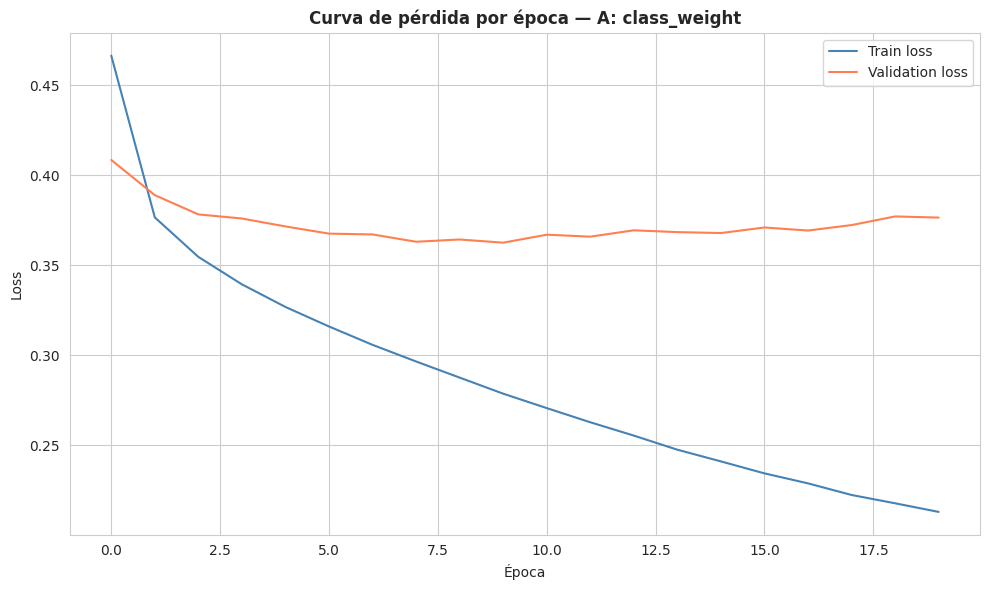


✓ Curva de pérdida por época generada


In [ ]:
print(f"\n{'='*80}")
print(f"VISUALIZACIÓN: CURVA DE PÉRDIDA POR ÉPOCA (TRAIN VS VALIDACIÓN)")
print(f"{'='*80}")

fig, ax = plt.subplots(figsize=(10, 6))

# Pérdida de entrenamiento y de validación por época, del modelo final ganador
ax.plot(history_final.history['loss'], label='Train loss', color='steelblue')
ax.plot(history_final.history['val_loss'], label='Validation loss', color='coral')
ax.set_title(f'Curva de pérdida por época — {nombre_ganador_mlp}', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ Curva de pérdida por época generada")



VISUALIZACIÓN: EJEMPLOS DE PREDICCIONES CORRECTAS E INCORRECTAS (MLP)


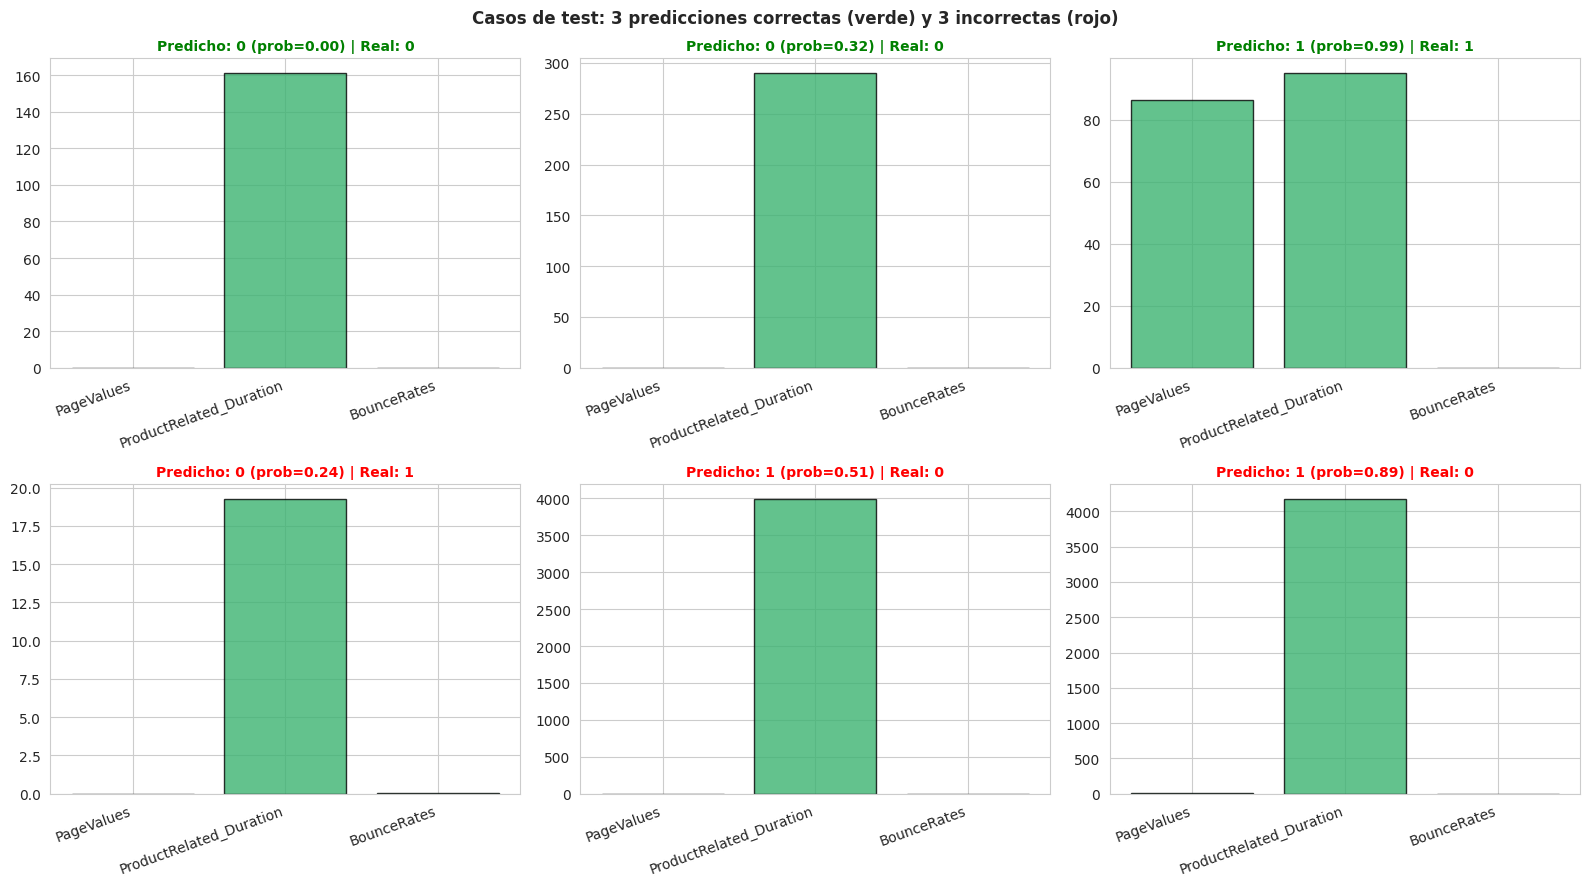


✓ Grilla de predicciones correctas/incorrectas generada


In [ ]:
print(f"\n{'='*80}")
print(f"VISUALIZACIÓN: EJEMPLOS DE PREDICCIONES CORRECTAS E INCORRECTAS (MLP)")
print(f"{'='*80}")

# Como el dataset es tabular (no imágenes), representamos cada caso de test como un
# gráfico de barras con 3 features clave, coloreando el título según acierto/fallo.
features_clave = ['PageValues', 'ProductRelated_Duration', 'BounceRates']

# Reconstruir un DataFrame de test con índice reiniciado, para alinear con y_pred_mlp/y_proba_mlp
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

aciertos_mask = (y_pred_mlp == y_test_reset.values)

# Índices de 3 casos acertados y 3 casos fallados (si existen suficientes de cada tipo)
idx_aciertos = np.where(aciertos_mask)[0][:3]
idx_fallos = np.where(~aciertos_mask)[0][:3]
idx_seleccionados = list(idx_aciertos) + list(idx_fallos)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, idx in enumerate(idx_seleccionados):
    ax = axes_flat[i]
    valores = X_test_reset.loc[idx, features_clave].astype(float)
    # Gráfico de barras con las 3 features clave del caso seleccionado
    ax.bar(features_clave, valores, color='mediumseagreen', edgecolor='black', alpha=0.8)
    ax.set_xticklabels(features_clave, rotation=20, ha='right')

    pred_i = int(y_pred_mlp[idx])
    real_i = int(y_test_reset.iloc[idx])
    proba_i = y_proba_mlp[idx]
    acierto = pred_i == real_i

    # Título en verde si acertó, rojo si falló, indicando predicho/probabilidad/real
    color_titulo = 'green' if acierto else 'red'
    ax.set_title(f"Predicho: {pred_i} (prob={proba_i:.2f}) | Real: {real_i}",
                 color=color_titulo, fontweight='bold', fontsize=10)

plt.suptitle('Casos de test: 3 predicciones correctas (verde) y 3 incorrectas (rojo)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Grilla de predicciones correctas/incorrectas generada")


In [ ]:
print(f"\n{'='*80}")
print(f"GUARDADO DEL MODELO MLP FINAL")
print(f"{'='*80}")


# Guardar el modelo Keras en formato nativo .keras (usando MODEL_OUTPUT_PATH de configuración)
ruta_modelo_mlp = 'mlp_trabajo_g03.keras'
mlp_final.save(ruta_modelo_mlp)

print(f"✓ Modelo MLP guardado en: {ruta_modelo_mlp}")



GUARDADO DEL MODELO MLP FINAL
✓ Modelo MLP guardado en: mlp_trabajo_g03.keras


---

## SECCIÓN 5: Comparación y Análisis

Comparamos el modelo kNN final (Sección 3) y el modelo MLP final (Sección 4) usando las variables ya presentes en memoria del mismo kernel (`y_test`, `y_pred_knn`, `y_proba_knn`, `y_pred_mlp`, `y_proba_mlp`), sin leer ni escribir archivos intermedios.


In [ ]:
print(f"\n{'='*80}")
print(f"TABLA COMPARATIVA FINAL: kNN VS MLP")
print(f"{'='*80}")

# y_test (Serie de pandas, Sección 2/3) e y_test_mlp (array, Sección 4) contienen los
# mismos valores/orden, ya que ambos provienen del mismo split; se usa y_test_mlp
# como referencia común para no depender del tipo (Serie vs array) en las métricas
tabla_comparativa_final = pd.DataFrame([
    {
        'Modelo': 'kNN',
        'Accuracy': round(accuracy_score(y_test, y_pred_knn), 4),
        'F1': round(f1_score(y_test, y_pred_knn), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba_knn), 4),
    },
    {
        'Modelo': 'MLP (Keras)',
        'Accuracy': round(accuracy_score(y_test_mlp, y_pred_mlp), 4),
        'F1': round(f1_score(y_test_mlp, y_pred_mlp), 4),
        'ROC-AUC': round(roc_auc_score(y_test_mlp, y_proba_mlp), 4),
    },
])

print(tabla_comparativa_final.to_string(index=False))
print(f"\n✓ Tabla comparativa final generada")



TABLA COMPARATIVA FINAL: kNN VS MLP
     Modelo  Accuracy     F1  ROC-AUC
        kNN    0.8098 0.5370   0.8511
MLP (Keras)    0.8358 0.6154   0.9137

✓ Tabla comparativa final generada



MATRICES DE CONFUSIÓN LADO A LADO: kNN VS MLP


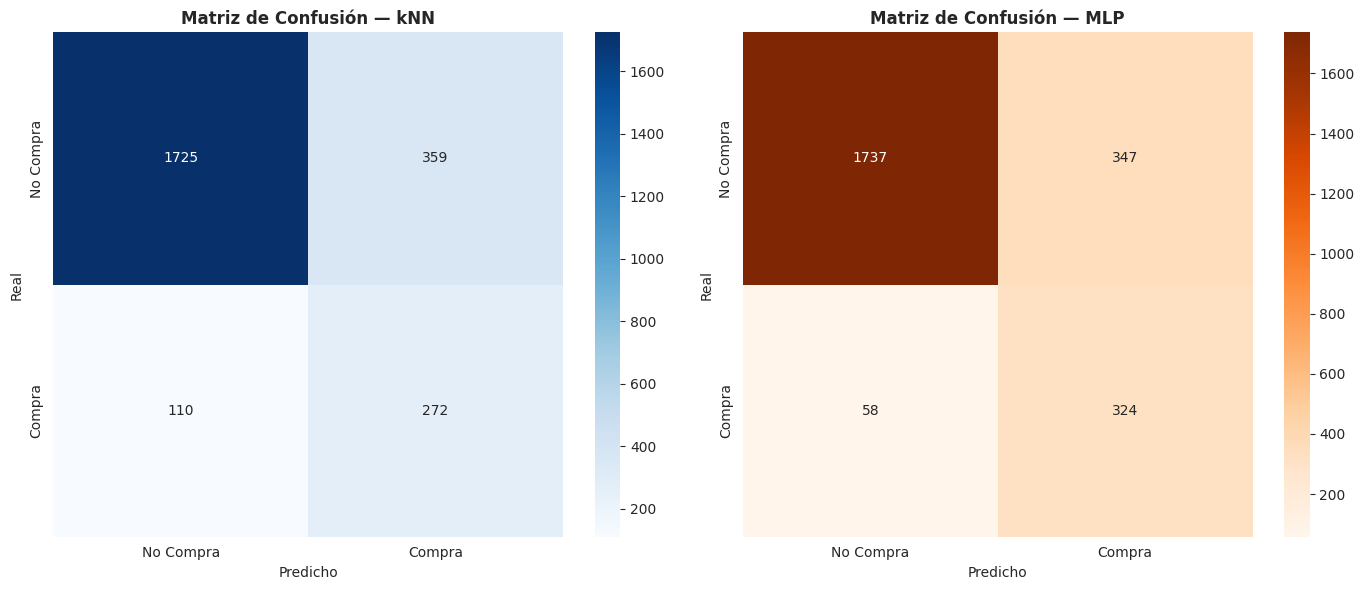


✓ Matrices de confusión lado a lado generadas


In [ ]:
print(f"\n{'='*80}")
print(f"MATRICES DE CONFUSIÓN LADO A LADO: kNN VS MLP")
print(f"{'='*80}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión del kNN final
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Compra', 'Compra'], yticklabels=['No Compra', 'Compra'])
axes[0].set_title('Matriz de Confusión — kNN', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz de confusión del MLP final
cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Compra', 'Compra'], yticklabels=['No Compra', 'Compra'])
axes[1].set_title('Matriz de Confusión — MLP', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print(f"\n✓ Matrices de confusión lado a lado generadas")



HISTOGRAMAS DE PROBABILIDADES PREDICHAS POR CLASE REAL: kNN VS MLP


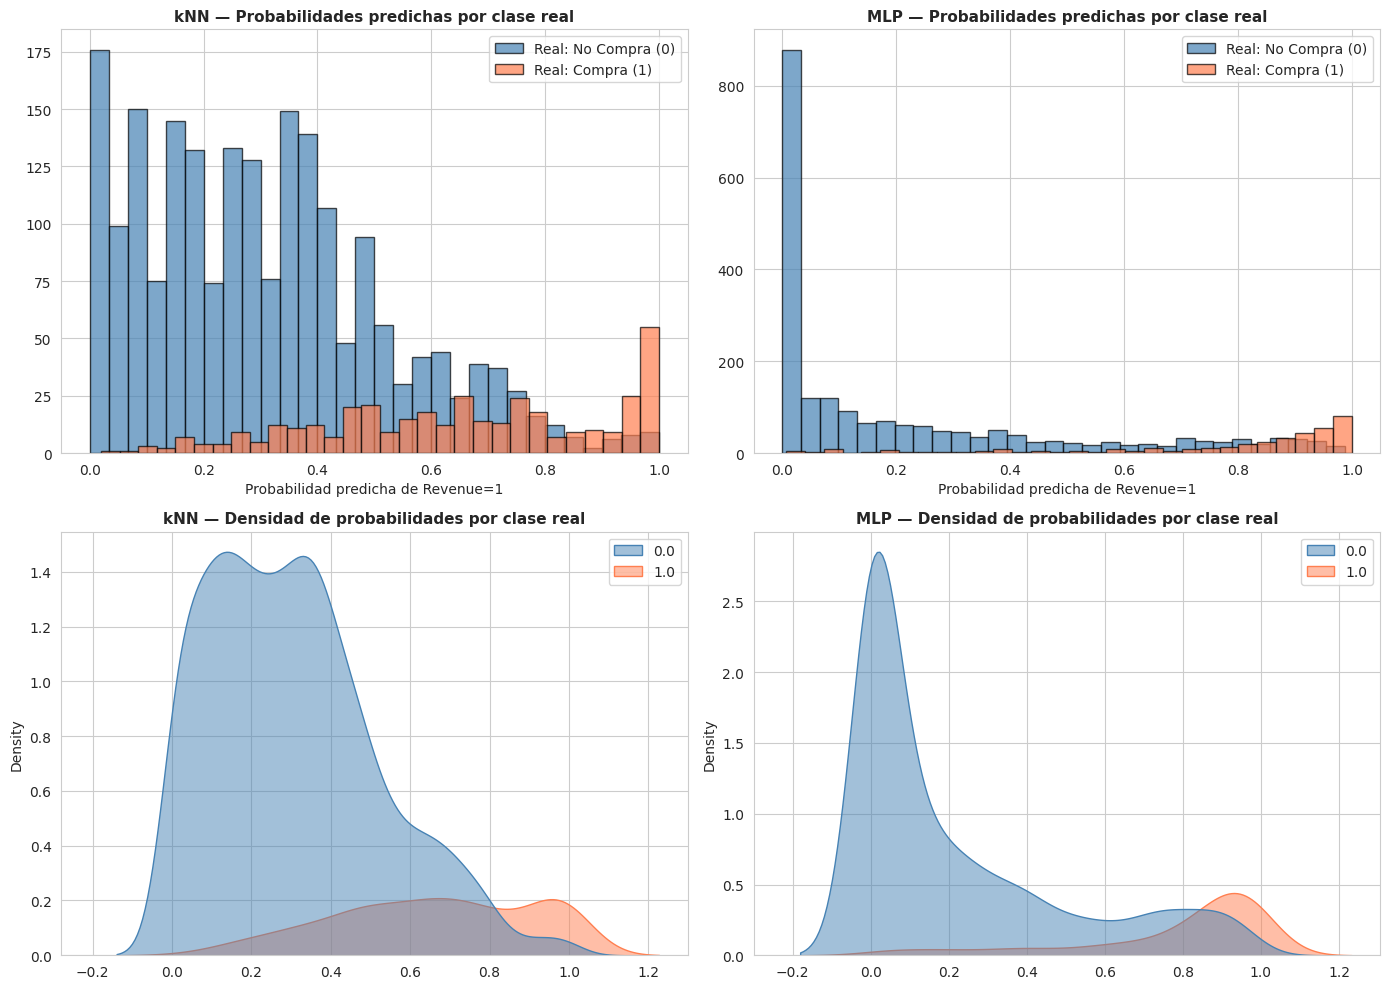


✓ Histogramas de probabilidades por clase real generados


In [ ]:
print(f"\n{'='*80}")
print(f"HISTOGRAMAS DE PROBABILIDADES PREDICHAS POR CLASE REAL: kNN VS MLP")
print(f"{'='*80}")

y_test_arr = np.asarray(y_test_mlp)  # referencia común de la clase real, alineada al split

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# kNN: histograma de probabilidades para la clase real 0 y para la clase real 1
axes[0, 0].hist(y_proba_knn[y_test_arr == 0], bins=30, color='steelblue', alpha=0.7,
                 edgecolor='black', label='Real: No Compra (0)')
axes[0, 0].hist(y_proba_knn[y_test_arr == 1], bins=30, color='coral', alpha=0.7,
                 edgecolor='black', label='Real: Compra (1)')
axes[0, 0].set_title('kNN — Probabilidades predichas por clase real', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('Probabilidad predicha de Revenue=1')
axes[0, 0].legend()

# MLP: mismo tipo de histograma superpuesto
axes[0, 1].hist(y_proba_mlp[y_test_arr == 0], bins=30, color='steelblue', alpha=0.7,
                 edgecolor='black', label='Real: No Compra (0)')
axes[0, 1].hist(y_proba_mlp[y_test_arr == 1], bins=30, color='coral', alpha=0.7,
                 edgecolor='black', label='Real: Compra (1)')
axes[0, 1].set_title('MLP — Probabilidades predichas por clase real', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Probabilidad predicha de Revenue=1')
axes[0, 1].legend()

# Fila inferior: versión con densidad (kdeplot) para comparar formas de distribución
sns.kdeplot(x=y_proba_knn, hue=y_test_arr, ax=axes[1, 0], fill=True,
            palette=['steelblue', 'coral'], alpha=0.5)
axes[1, 0].set_title('kNN — Densidad de probabilidades por clase real', fontweight='bold', fontsize=11)

sns.kdeplot(x=y_proba_mlp, hue=y_test_arr, ax=axes[1, 1], fill=True,
            palette=['steelblue', 'coral'], alpha=0.5)
axes[1, 1].set_title('MLP — Densidad de probabilidades por clase real', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n✓ Histogramas de probabilidades por clase real generados")


### Ventajas y limitaciones de cada método sobre este dataset

**kNN**:
- Ventaja: es un modelo directamente interpretable — cada predicción puede explicarse mostrando los k vecinos más cercanos y su "voto" (Sección 3), lo cual es valioso para justificar decisiones ante negocio.
- Limitación: sufre la "maldición de la dimensionalidad" tras el One-Hot Encoding, ya que 63 de las ~74 columnas finales son dummies dispersos (mayormente ceros) que diluyen el significado de la distancia euclidiana entre puntos. Además, kNN no soporta pesos de clase nativos, por lo que el desbalanceo debió compensarse externamente con SMOTE/undersampling.

**MLP (Keras)**:
- Ventaja: puede aprender relaciones no lineales complejas entre las variables de navegación, y soporta de forma nativa mecanismos de balanceo (`class_weight`, `BinaryFocalCrossentropy`) sin necesidad de pipelines externos de resampling.
- Limitación: requiere más esfuerzo de tuning (arquitectura, tasa de aprendizaje, épocas, balanceo) y es un modelo de caja negra — mucho menos interpretable que kNN para explicar una predicción individual ante un stakeholder de negocio.

### Aplicación real

Un modelo de este tipo tiene aplicaciones directas en e-commerce:

- **Retargeting**: identificar en tiempo real sesiones con alta probabilidad de compra para activar campañas de remarketing (descuentos, recordatorios) antes de que el usuario abandone el sitio.
- **Priorización de soporte al cliente**: enrutar sesiones con alta intención de compra pero baja confianza del modelo hacia chat en vivo o asistencia proactiva.
- **Recomendación en tiempo real**: ajustar dinámicamente la oferta de productos o promociones mostradas según la intención de compra detectada durante la navegación de la sesión activa.


### Conclusiones

In [ ]:
print(f"\n\n{'='*80}")
print(f"ANÁLISIS COMPLETADO")
print(f"{'='*80}")

# Determinar cuál de los dos modelos finales tuvo mejor F1 en test, como criterio de cierre
mejor_modelo = tabla_comparativa_final.loc[tabla_comparativa_final['F1'].idxmax(), 'Modelo']

print(f"""
Dataset: Online Shoppers Purchasing Intention (UCI) — {df.shape[0]} sesiones, {df.shape[1]} variables.
Target: Revenue (compra sí/no) — desbalanceado ~84.5% / 15.5%.

MODELO kNN (Sección 3):
- Pipeline ganador: {nombre_ganador}
- Accuracy: {acc_knn:.4f} | F1: {f1_knn:.4f} | ROC-AUC: {roc_auc_knn:.4f}
- Modelo guardado en: {ruta_modelo_knn}

MODELO MLP (Sección 4):
- Configuración ganadora: {nombre_ganador_mlp}
- Accuracy: {acc_mlp:.4f} | F1: {f1_mlp:.4f} | ROC-AUC: {roc_auc_mlp:.4f}
- Modelo guardado en: {ruta_modelo_mlp}

COMPARACIÓN FINAL:
{tabla_comparativa_final.to_string(index=False)}

Mejor modelo según F1 en test: {mejor_modelo}

kNN destaca por su interpretabilidad directa (votos de vecinos), mientras que el MLP
maneja mejor la no linealidad y el desbalanceo de forma nativa, a costa de ser menos
interpretable. La elección en producción dependería de si prima la explicabilidad
(kNN) o el desempeño puro y la escalabilidad (MLP).
""")




ANÁLISIS COMPLETADO

Dataset: Online Shoppers Purchasing Intention (UCI) — 12330 sesiones, 18 variables.
Target: Revenue (compra sí/no) — desbalanceado ~84.5% / 15.5%.

MODELO kNN (Sección 3):
- Pipeline ganador: RandomUnderSampler
- Accuracy: 0.8098 | F1: 0.5370 | ROC-AUC: 0.8511
- Modelo guardado en: knn_trabajo_g03.joblib

MODELO MLP (Sección 4):
- Configuración ganadora: A: class_weight
- Accuracy: 0.8358 | F1: 0.6154 | ROC-AUC: 0.9137
- Modelo guardado en: mlp_trabajo_g03.keras

COMPARACIÓN FINAL:
     Modelo  Accuracy     F1  ROC-AUC
        kNN    0.8098 0.5370   0.8511
MLP (Keras)    0.8358 0.6154   0.9137

Mejor modelo según F1 en test: MLP (Keras)

kNN destaca por su interpretabilidad directa (votos de vecinos), mientras que el MLP
maneja mejor la no linealidad y el desbalanceo de forma nativa, a costa de ser menos
interpretable. La elección en producción dependería de si prima la explicabilidad
(kNN) o el desempeño puro y la escalabilidad (MLP).

